In [ ]:
# ============================================================================
# ExNCDIA - RDKit pipeline (RDKit_GA models)
#
# Required files in the working directory:
#   - ExNCDIA_trainingset_RDKit_descriptors.csv, ExNCDIA_testset_RDKit_descriptors.csv
#         training/test feature tables (produced by prepare_datasets.py)
#   - X_train_GA_RDKit.csv, X_test_GA_RDKit.csv
#         precomputed RDKit_GA 85-feature subset (already standardized and selected)
#
# How to run: execute the cells top to bottom. The genetic algorithm in Section 4.4 is
# very slow (it can take hours) and can be skipped - the cell right after it loads the
# precomputed RDKit_GA subset, which is what the five models actually use.
#
# Outputs: per-model 10-fold CV and test-set metrics, a ROC comparison plot, SHAP plots.
# Tested with scikit-learn 1.5.1, imbalanced-learn 0.12.3, lightgbm 3.3.5, xgboost 1.6.1,
# hyperopt 0.2.7, shap 0.41.0 (see requirements.txt).
# ============================================================================

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, mutual_info_classif as MIC
from sklearn.model_selection import KFold, cross_validate, cross_val_score
from sklearn.metrics import (roc_auc_score, accuracy_score, confusion_matrix,
                             matthews_corrcoef, make_scorer, roc_curve, auc)
from imblearn.ensemble import BalancedRandomForestClassifier

In [12]:
# 1. Data loading
# Training and test sets are stored separately; no random splitting is applied here.
# Adjust LABEL_COL / DROP_COLS below if your files use a different column layout.
LABEL_COL = "Label"
DROP_COLS = ["Pubchem CID", "Label", "Data Set", "Standardized_SMILES"]

# 1.1 Training set
training_set = pd.read_csv("ExNCDIA_trainingset_RDKit_descriptors.csv")
Xtrain = training_set.drop(columns=[c for c in DROP_COLS if c in training_set.columns])
Ytrain = training_set[LABEL_COL]
print(Ytrain.value_counts())

Label
0    428
1    296
Name: count, dtype: int64


In [13]:
# 1.2 Test set
test_set = pd.read_csv("ExNCDIA_testset_RDKit_descriptors.csv")
Xtest = test_set.drop(columns=[c for c in DROP_COLS if c in test_set.columns])
Ytest = test_set[LABEL_COL]
print(Ytest.value_counts())

Label
0    107
1     75
Name: count, dtype: int64


In [14]:
# 2. Feature preprocessing (FP)

def preprocess_features(X_train, X_test, standardize=True):
    """
    Feature preprocessing: missing-value removal, standardization, variance
    threshold, and Pearson correlation filtering.

    Args:
        X_train, X_test (pd.DataFrame): training and test features
        standardize (bool): z-score standardization (True for continuous
            descriptors, False for binary fingerprints)

    Returns:
        X_train_processed, X_test_processed (pd.DataFrame)
    """
    n_start = X_train.shape[1]
    print("Missing values -> train:", X_train.isnull().sum().sum(),
          "| test:", X_test.isnull().sum().sum())

    # 2.1 drop features containing missing values
    X_train = X_train.loc[:, X_train.notnull().all()]
    X_test = X_test[X_train.columns]

    # 2.2 z-score standardization (continuous descriptors only)
    if standardize:
        scaler = StandardScaler()
        X_train = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=X_train.columns, index=X_train.index)
        X_test = pd.DataFrame(scaler.transform(X_test),
                              columns=X_test.columns, index=X_test.index)
        joblib.dump(scaler, "scaler_RDKit.pkl")

    # 2.3 remove zero-variance features
    selector = VarianceThreshold().fit(X_train)
    keep_vars = X_train.columns[selector.variances_ != 0].tolist()
    X_train, X_test = X_train[keep_vars], X_test[keep_vars]

    # 2.4 remove highly correlated features (|r| > 0.9)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop_features = [c for c in upper.columns if any(upper[c] > 0.9)]
    X_train_processed = X_train.drop(columns=drop_features)
    X_test_processed = X_test.drop(columns=drop_features)

    print(f"Features reduced from {n_start} to {X_train_processed.shape[1]}")
    X_train_processed.to_csv("X_train_processed_RDKit.csv", index=False)
    X_test_processed.to_csv("X_test_processed_RDKit.csv", index=False)
    return X_train_processed, X_test_processed

In [15]:
X_train_processed, X_test_processed = preprocess_features(Xtrain, Xtest, standardize=True)
X_train_processed

Missing values -> train: 0 | test: 0
Features reduced from 198 to 157


,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,MaxPartialCharge,MinPartialCharge,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,...,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0.822267,0.278542,-0.267280,-0.187656,0.763613,0.073703,0.474324,-0.582960,0.786903,0.198095,...,-0.17101,-0.265025,-0.217375,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
1,0.489274,0.606020,-0.518544,1.324543,-0.429189,0.834991,-0.485355,0.376580,-0.556003,0.092124,...,-0.17101,-0.265025,-0.217375,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
2,0.880037,-1.380239,-0.369614,-0.890761,0.730928,-0.137516,-1.148939,-0.079201,-0.571495,-1.812650,...,-0.17101,-0.265025,-0.217375,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
3,-2.456193,1.480617,2.817084,0.634126,-0.727703,-1.346119,1.340448,0.347056,3.934628,0.735385,...,4.98780,-0.265025,-0.217375,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
4,0.559989,0.382031,-0.575987,1.428614,-0.429189,-0.165753,0.380640,0.184672,-0.576584,0.006633,...,-0.17101,-0.265025,-0.217375,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,0.110232,-0.203645,-0.299937,-0.807666,-0.148199,0.174827,0.395315,0.827564,0.789984,0.166332,...,-0.17101,-0.265025,-0.217375,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
720,0.242000,-1.991810,-0.738396,1.404775,-0.484368,0.724632,1.171007,0.602354,0.786903,1.439471,...,-0.17101,-0.265025,3.529748,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,5.083048
721,-0.034003,-1.990121,-0.079350,0.301591,-0.777635,0.154664,2.051648,2.007799,0.556777,2.889895,...,-0.17101,-0.265025,3.529748,-0.083391,-0.074536,-0.135219,-0.153501,-0.166776,-0.197266,-0.166776
722,0.644329,-0.191192,-0.406625,-2.283482,1.529207,0.947021,-0.730636,0.984289,0.551111,0.176513,...,-0.17101,6.587767,-0.217375,-0.083391,-0.074536,-0.135219,5.403249,-0.166776,-0.197266,-0.166776


In [16]:
"""
3. Base model for feature selection

A Balanced Random Forest is used as the base estimator for the embedded/wrapper
feature-selection methods. Its hyperparameters were obtained with the same Hyperopt
procedure used for the models in Section 5 (see optimize_brf in Section 5.1) and are set
directly below for reproducibility.
"""

def get_model_performance(X, y, model_params, random_state=1):
    """10-fold cross-validation metrics (mean across the 10 folds) for a Balanced Random Forest."""
    model = BalancedRandomForestClassifier(**model_params)
    cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
    scoring = {"AUC": "roc_auc", "ACC": "accuracy", "SEN": "recall", "MCC": "matthews_corrcoef"}
    cv_res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, error_score="raise")

    acc = np.mean(cv_res["test_ACC"])
    sen = np.mean(cv_res["test_SEN"])
    n_pos, n_neg = int((y == 1).sum()), int((y == 0).sum())
    cv_mean = {
        "AUC": np.mean(cv_res["test_AUC"]),
        "ACC": acc,
        "SEN": sen,
        "SPE": (len(y) * acc - sen * n_pos) / n_neg,   # specificity from CV accuracy and sensitivity
        "MCC": np.mean(cv_res["test_MCC"]),
    }
    order = ["AUC", "ACC", "SEN", "SPE", "MCC"]
    return pd.DataFrame({"Metric": order, "10-fold CV": [cv_mean[m] for m in order]})

In [20]:
# base estimator for the embedded/wrapper selectors (parameters from optimize_brf, Section 5.1)
base_params = {
    "n_estimators":245,
    "criterion": "entropy",
    "max_depth": 14,
    "max_features": 51,
    "bootstrap": True,
    "sampling_strategy": "auto",
    "replacement": False,
    "random_state": 1,
    "verbose": False,
    "n_jobs": -1,
}
print(get_model_performance(X_train_processed, Ytrain, base_params).to_string(index=False, float_format="%.3f"))

best_model_preprocessing = BalancedRandomForestClassifier(**base_params)
best_model_preprocessing.fit(X_train_processed, Ytrain)

Metric  10-fold CV
   AUC       0.820
   ACC       0.742
   SEN       0.739
   SPE       0.743
   MCC       0.481


BalancedRandomForestClassifier(bootstrap=True, criterion='entropy',
                               max_depth=14, max_features=51, n_estimators=245,
                               n_jobs=-1, random_state=1, replacement=False,
                               sampling_strategy='auto', verbose=False)

In [ ]:
"""
4. Feature selection

Five strategies were evaluated for the RDKit descriptors (Table S3): an ANOVA F-test
(p < 0.05), mutual information (MI > 0), embedded tree-based selection (ETB), RFECV, and a
genetic algorithm (GA). The GA gave the best 10-fold cross-validation performance and is
run below; the other four are provided as templates.
"""

# 4.1 ANOVA F-test: keep features with p < 0.05
def f_test_selection(X, y, alpha=0.05):
    from sklearn.feature_selection import f_classif
    F, p = f_classif(X, y)
    selected = X.columns[p < alpha].tolist()
    return X[selected], pd.Series(p, index=X.columns)

# 4.2 Mutual information: keep features with MI > 0
def mutual_information_selection(X, y, random_state=0):
    np.random.seed(random_state)
    mi_scores = MIC(X, y)
    selected = X.columns[mi_scores > 0].tolist()
    return X[selected], pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 4.3 Embedded tree-based: keep features with importance >= 0.001
def embedded_feature_selection(model, X, importance_threshold=0.001):
    mask = model.feature_importances_ >= importance_threshold
    selected = model.feature_names_in_[mask]
    return X[selected]

# 4.4 RFECV: optimal subset size chosen by 10-fold CV
def rfecv_selection(X, y, estimator, cv=10):
    rfecv = RFECV(estimator=estimator, step=1, cv=cv, scoring="matthews_corrcoef").fit(X, y)
    return X[rfecv.get_feature_names_out()], rfecv

# Example usage (not run here):
# X_train_ftest, p_values = f_test_selection(X_train_processed, Ytrain)
# X_train_mi, mi_scores = mutual_information_selection(X_train_processed, Ytrain)
# X_train_etb = embedded_feature_selection(best_model_preprocessing, X_train_processed)
# X_train_rfecv, rfecv = rfecv_selection(X_train_processed, Ytrain, best_model_preprocessing)

In [ ]:
# 4.5 Genetic algorithm feature selection (GA)
#
# NOTE: this GA search is very slow (it can take hours). You do NOT need to run this
# cell -- the resulting RDKit_GA subset is loaded directly in the next cell. The code
# below is kept only to document how the 85-feature subset was generated.
from deap import base, creator, tools, algorithms
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

feature_names = X_train_processed.columns
X_train_arr = X_train_processed.values
y_train_arr = Ytrain.values

def evaluate(individual):
    cols = [i for i, bit in enumerate(individual) if bit == 1]
    if not cols:
        return -1,
    clf = BalancedRandomForestClassifier(
        n_estimators=245, criterion="entropy", max_depth=14, max_features=51,
        bootstrap=True, sampling_strategy="auto", replacement=False,
        random_state=1, verbose=False, n_jobs=-1)
    scores = cross_val_score(clf, X_train_arr[:, cols], y_train_arr,
                             cv=10, scoring=make_scorer(matthews_corrcoef))
    return scores.mean(),

NUM_GENES = X_train_arr.shape[1]
POP_SIZE, NGEN, CXPB, MUTPB = 50, 40, 0.5, 0.2

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", np.random.randint, 2)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=NUM_GENES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

hof = tools.HallOfFame(1)
population = toolbox.population(n=POP_SIZE)
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                          ngen=NGEN, stats=None, halloffame=hof, verbose=True)

best_individual = hof[0]
selected_idx = [i for i, bit in enumerate(best_individual) if bit == 1]
selected_feature_names = feature_names[selected_idx]
print(f"Selected {len(selected_feature_names)} features")
print(f"Best CV MCC: {evaluate(best_individual)[0]:.3f}")

X_train_selected = X_train_processed[selected_feature_names]

In [ ]:
# 4.6 Selecting the best feature subset
#
# Each candidate subset (FP and the five selection methods) is compared by tuning a
# Balanced Random Forest on it with Hyperopt (10-fold CV, MCC) and comparing the mean CV
# MCC; the subset with the best CV MCC is chosen for the final models. For the RDKit
# descriptors this procedure selected the GA subset. The five classifiers are then tuned
# on the chosen subset (Section 5). This search is slow and is shown for documentation
# only (NOT run here).
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss

def tune_brf_cv_mcc(X, y, max_evals=250, random_state=1):
    """Tune a Balanced Random Forest on X (Hyperopt, 10-fold CV, MCC); return (best_params, cv_mcc)."""
    mf = ["sqrt", "log2", *range(2, 60)]
    def objective(params):
        model = BalancedRandomForestClassifier(
            n_estimators=int(params["n_estimators"]), criterion=params["criterion"],
            max_depth=int(params["max_depth"]), max_features=params["max_features"],
            sampling_strategy="auto", replacement=False, random_state=random_state, n_jobs=-1)
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        return -np.mean(cross_validate(model, X, y, cv=cv, scoring="matthews_corrcoef",
                                       n_jobs=-1, error_score="raise")["test_score"])
    space = {"n_estimators": hp.quniform("n_estimators", 40, 330, 1),
             "criterion": hp.choice("criterion", ["gini", "entropy"]),
             "max_depth": hp.quniform("max_depth", 2, 15, 1),
             "max_features": hp.choice("max_features", mf)}
    trials = Trials()
    best = fmin(objective, space, algo=tpe.suggest, max_evals=max_evals, trials=trials,
                early_stop_fn=no_progress_loss(400), verbose=False)
    best_params = {"n_estimators": int(best["n_estimators"]),
                   "criterion": ["gini", "entropy"][best["criterion"]],
                   "max_depth": int(best["max_depth"]), "max_features": mf[best["max_features"]]}
    return best_params, -min(trials.losses())

# Example usage (not run here; tuning every subset is very slow):
# candidate_subsets = {
#     "FP":     X_train_processed,
#     "F-test": f_test_selection(X_train_processed, Ytrain)[0],
#     "MI":     mutual_information_selection(X_train_processed, Ytrain)[0],
#     "ETB":    embedded_feature_selection(best_model_preprocessing, X_train_processed),
#     "RFECV":  rfecv_selection(X_train_processed, Ytrain, best_model_preprocessing)[0],
#     "GA":     X_train_processed[selected_feature_names],
# }
# subset_scores = {}
# for name, X_sub in candidate_subsets.items():
#     best_params, cv_mcc = tune_brf_cv_mcc(X_sub, Ytrain)
#     subset_scores[name] = cv_mcc
#     print(f"{name:7s}  CV MCC = {cv_mcc:.3f}  ({X_sub.shape[1]} features)  best={best_params}")
# best_subset = max(subset_scores, key=subset_scores.get)
# print("Best subset:", best_subset)

In [21]:
# The genetic algorithm above is very slow, so we load the previously GA-selected
# feature subset (RDKit_GA, 85 features) directly. These tables are already preprocessed
# (z-scored) and feature-selected; the labels Ytrain / Ytest defined in Section 1 are
# reused as-is (their row order matches the train/test split used to build these tables).
X_train_selected = pd.read_csv("X_train_GA_RDKit.csv")
X_test_selected = pd.read_csv("X_test_GA_RDKit.csv")
selected_feature_names = X_train_selected.columns
print("RDKit_GA subset ->", X_train_selected.shape, X_test_selected.shape)

RDKit_GA subset -> (724, 85) (182, 85)


In [22]:
"""
5. Model development and evaluation

The GA-selected RDKit subset (RDKit_GA) is used to build and evaluate five imbalance-aware
ensemble classifiers. For each model the Hyperopt optimization routine is provided as a
template, and the optimized hyperparameters obtained in our experiments are set directly so
that the reported performance can be reproduced. Each model is assessed by 10-fold
cross-validation, out-of-fold prediction, and the independent test set.
"""

def evaluate_model_performance(model, X_train, y_train, X_test, y_test):
    """10-fold cross-validation (mean across the 10 folds) and independent test-set metrics.

    AUC/ACC/SEN/MCC are averaged over the 10 validation folds; CV specificity is derived
    from the CV accuracy and sensitivity.
    """
    cv = KFold(n_splits=10, shuffle=True, random_state=1)
    scoring = {"AUC": "roc_auc", "ACC": "accuracy", "SEN": "recall", "MCC": "matthews_corrcoef"}
    cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring,
                            n_jobs=-1, error_score="raise")
    acc = np.mean(cv_res["test_ACC"])
    sen = np.mean(cv_res["test_SEN"])
    n_pos, n_neg = int((y_train == 1).sum()), int((y_train == 0).sum())
    cv_mean = {
        "AUC": np.mean(cv_res["test_AUC"]),
        "ACC": acc,
        "SEN": sen,
        "SPE": (len(y_train) * acc - sen * n_pos) / n_neg,
        "MCC": np.mean(cv_res["test_MCC"]),
    }

    # independent test set
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    test = {
        "AUC": roc_auc_score(y_test, y_proba_test),
        "ACC": accuracy_score(y_test, y_pred_test),
        "SEN": tp / (tp + fn),
        "SPE": tn / (tn + fp),
        "MCC": matthews_corrcoef(y_test, y_pred_test),
    }

    order = ["AUC", "ACC", "SEN", "SPE", "MCC"]
    results = pd.DataFrame({"Metric": order,
                            "10-fold CV": [cv_mean[m] for m in order],
                            "Test": [test[m] for m in order]})
    confusion = pd.DataFrame({"Confusion_matrix": [tp, fn, fp, tn]}, index=["TP", "FN", "FP", "TN"])
    return results, confusion

In [23]:
"""
5.1 Balanced Random Forest (BRF) - hyperparameter optimization
"""
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss


def optimize_brf(X, y, random_state=1):
    """Optimize Balanced Random Forest hyperparameters with Hyperopt (10-fold CV, MCC)."""
    def objective(params):
        model = BalancedRandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            criterion=params["criterion"],
            max_depth=int(params["max_depth"]),
            max_features=params["max_features"],
            sampling_strategy="auto", replacement=False,
            random_state=random_state, n_jobs=-1)
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(model, X, y, cv=cv, scoring="matthews_corrcoef",
                                n_jobs=-1, error_score="raise")
        return -np.mean(scores["test_score"])

    mf = ["sqrt", "log2", *range(2, 60)]
    param_space = {
        "n_estimators": hp.quniform("n_estimators", 40, 330, 1),
        "criterion": hp.choice("criterion", ["gini", "entropy"]),
        "max_depth": hp.quniform("max_depth", 2, 15, 1),
        "max_features": hp.choice("max_features", mf),
    }
    trials = Trials()
    best = fmin(objective, param_space, algo=tpe.suggest, max_evals=250,
                trials=trials, early_stop_fn=no_progress_loss(400), verbose=True)
    return {"n_estimators": int(best["n_estimators"]),
            "criterion": ["gini", "entropy"][best["criterion"]],
            "max_depth": int(best["max_depth"]),
            "max_features": mf[best["max_features"]]}

# Example usage (slow; run once to reproduce the search):
# best = optimize_brf(X_train_selected, Ytrain)
# print(best)

In [24]:
"""
5.1 Balanced Random Forest (BRF) - best model
"""
# Best parameter combination found by the Hyperopt search above:
best_params_brf = {
    "n_estimators": 320,
    "criterion": "entropy",
    "max_depth": 12,
    "max_features": 54,
    "bootstrap": True,
    "sampling_strategy": "auto",
    "replacement": False,
    "random_state": 1,
    "verbose": False,
    "n_jobs": -1,
}

model_brf = BalancedRandomForestClassifier(**best_params_brf)
model_brf.fit(X_train_selected, Ytrain)

results_brf, cm_brf = evaluate_model_performance(model_brf, X_train_selected, Ytrain, X_test_selected, Ytest)
print(results_brf.to_string(index=False, float_format="%.3f"))
print(cm_brf)

Metric  10-fold CV  Test
   AUC       0.834 0.850
   ACC       0.759 0.797
   SEN       0.749 0.813
   SPE       0.767 0.785
   MCC       0.515 0.591
    Confusion_matrix
TP                61
FN                14
FP                23
TN                84


In [25]:
"""
5.2 Easy Ensemble Classifier (EEC) - hyperparameter optimization
"""
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss


def optimize_eec(X, y, random_state=1):
    """Optimize Easy Ensemble hyperparameters with Hyperopt (10-fold CV, MCC)."""
    def objective(params):
        base = DecisionTreeClassifier(max_depth=int(params["base_estimator_max_depth"]),
                                      random_state=random_state)
        model = EasyEnsembleClassifier(
            n_estimators=10,
            estimator=AdaBoostClassifier(estimator=base,
                                         n_estimators=int(params["n_estimators"]),
                                         learning_rate=params["learning_rate"],
                                         algorithm=params["algorithm"],
                                         random_state=random_state),
            random_state=random_state, n_jobs=-1)
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(model, X, y, cv=cv, scoring="matthews_corrcoef",
                                n_jobs=-1, error_score="raise")
        return -np.mean(scores["test_score"])

    # the AdaBoost learning rate and algorithm are held fixed; only the ensemble size
    # and the base-tree depth are searched
    param_space = {
        "n_estimators": hp.quniform("n_estimators", 50, 400, 1),
        "learning_rate": 0.99,
        "algorithm": "SAMME.R",
        "base_estimator_max_depth": hp.quniform("base_estimator_max_depth", 1, 6, 1),
    }
    trials = Trials()
    best = fmin(objective, param_space, algo=tpe.suggest, max_evals=200,
                trials=trials, early_stop_fn=no_progress_loss(100), verbose=True)
    return {"n_estimators": int(best["n_estimators"]),
            "base_estimator_max_depth": int(best["base_estimator_max_depth"]),
            "learning_rate": 0.99, "algorithm": "SAMME.R"}

# Example usage (slow; run once to reproduce the search):
# best = optimize_eec(X_train_selected, Ytrain)
# print(best)

In [26]:
"""
5.2 Easy Ensemble Classifier (EEC) - best model
"""
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Best parameter combination found by the Hyperopt search above:
model_eec = EasyEnsembleClassifier(
    n_estimators=10,
    estimator=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, random_state=1),
        n_estimators=347,
        learning_rate=0.984,
        algorithm="SAMME.R",
        random_state=1),
    random_state=1, n_jobs=-1)

results_eec, cm_eec = evaluate_model_performance(model_eec, X_train_selected, Ytrain, X_test_selected, Ytest)
print(results_eec.to_string(index=False, float_format="%.3f"))
print(cm_eec)

Metric  10-fold CV  Test
   AUC       0.830 0.845
   ACC       0.754 0.747
   SEN       0.752 0.733
   SPE       0.755 0.757
   MCC       0.503 0.486
    Confusion_matrix
TP                55
FN                20
FP                26
TN                81


In [27]:
"""
5.3 XGBoost with Balanced Bagging (BBC+XGBoost) - hyperparameter optimization
"""
from xgboost import XGBClassifier as XGBC
from imblearn.ensemble import BalancedBaggingClassifier
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss


def optimize_xgb(X, y, random_state=1):
    """Optimize XGBoost (Balanced Bagging) hyperparameters with Hyperopt (10-fold CV, MCC)."""
    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    def objective(params):
        booster = ["gbtree", "gblinear", "dart"][params["booster"]]
        base = XGBC(
            n_estimators=int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            booster=booster,
            colsample_bytree=params["colsample_bytree"],
            colsample_bynode=params["colsample_bynode"],
            gamma=params["gamma"],
            reg_lambda=params["reg_lambda"],
            min_child_weight=int(params["min_child_weight"]),
            max_depth=int(params["max_depth"]),
            subsample=params["subsample"],
            scale_pos_weight=scale_pos_weight,
            random_state=random_state, verbosity=0, n_jobs=-1)
        model = BalancedBaggingClassifier(n_estimators=10, estimator=base, random_state=random_state)
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(model, X, y, cv=cv, scoring="matthews_corrcoef",
                                n_jobs=-1, error_score="raise")
        return -np.mean(scores["test_score"])

    param_space = {
        "n_estimators": hp.quniform("n_estimators", 40, 350, 1),
        "learning_rate": hp.quniform("learning_rate", 0.01, 1.0, 0.01),
        "booster": hp.choice("booster", [0, 1, 2]),
        "colsample_bytree": hp.quniform("colsample_bytree", 0.3, 1, 0.1),
        "colsample_bynode": hp.quniform("colsample_bynode", 0.3, 1, 0.1),
        "gamma": hp.loguniform("gamma", -5, 0),
        "reg_lambda": hp.loguniform("reg_lambda", -5, 0),
        "min_child_weight": hp.quniform("min_child_weight", 1, 10, 1),
        "max_depth": hp.quniform("max_depth", 2, 10, 1),
        "subsample": hp.quniform("subsample", 0.3, 1, 0.1),
    }
    trials = Trials()
    best = fmin(objective, param_space, algo=tpe.suggest, max_evals=250,
                trials=trials, early_stop_fn=no_progress_loss(400), verbose=True)
    best["booster"] = ["gbtree", "gblinear", "dart"][best["booster"]]
    return best

# Example usage (slow; run once to reproduce the search):
# best = optimize_xgb(X_train_selected, Ytrain)
# print(best)

In [35]:
"""
5.3 XGBoost with Balanced Bagging (BBC+XGBoost) - best model
"""
from xgboost import XGBClassifier as XGBC
from imblearn.ensemble import BalancedBaggingClassifier

scale_pos_weight = (Ytrain == 0).sum() / (Ytrain == 1).sum()

# Best parameter combination found by the Hyperopt search above:
xgb = XGBC(
    n_estimators=297,
    learning_rate=0.41,
    booster="dart",
    colsample_bytree=1.0,
    colsample_bynode=0.8,
    gamma=0.07746669588566146,
    reg_lambda=0.5187364770939622,
    min_child_weight=2,
    max_depth=10,
    subsample=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=1, verbosity=0, n_jobs=-1)
model_xgb = BalancedBaggingClassifier(n_estimators=10, estimator=xgb, random_state=1)

results_xgb, cm_xgb = evaluate_model_performance(model_xgb, X_train_selected, Ytrain, X_test_selected, Ytest)
print(results_xgb.to_string(index=False, float_format="%.3f"))
print(cm_xgb)

Metric  10-fold CV  Test
   AUC       0.820 0.823
   ACC       0.750 0.747
   SEN       0.741 0.760
   SPE       0.756 0.738
   MCC       0.495 0.492
    Confusion_matrix
TP                57
FN                18
FP                28
TN                79


In [29]:
"""
5.4 Gradient Boosting with Balanced Bagging (BBC+GBDT) - hyperparameter optimization
"""
from sklearn.ensemble import GradientBoostingClassifier as GBC
from imblearn.ensemble import BalancedBaggingClassifier
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss


def optimize_gbc(X, y, random_state=1):
    """Optimize Gradient Boosting (Balanced Bagging) hyperparameters with Hyperopt (10-fold CV, MCC)."""
    def objective(params):
        base = GBC(
            n_estimators=int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            criterion=params["criterion"],
            max_depth=int(params["max_depth"]),
            max_features=params["max_features"],
            subsample=params["subsample"],
            random_state=random_state)
        model = BalancedBaggingClassifier(n_estimators=10, estimator=base, random_state=random_state)
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(model, X, y, cv=cv, scoring="matthews_corrcoef",
                                n_jobs=-1, error_score="raise")
        return -np.mean(scores["test_score"])

    mf = ["sqrt", "log2", *range(2, 60)]
    param_space = {
        "n_estimators": hp.quniform("n_estimators", 25, 350, 1),
        "learning_rate": hp.quniform("learning_rate", 0.1, 1.0, 0.01),
        "criterion": hp.choice("criterion", ["friedman_mse", "squared_error"]),
        "max_depth": hp.quniform("max_depth", 2, 10, 1),
        "subsample": hp.quniform("subsample", 0.5, 1.0, 0.01),
        "max_features": hp.choice("max_features", mf),
    }
    trials = Trials()
    best = fmin(objective, param_space, algo=tpe.suggest, max_evals=250,
                trials=trials, early_stop_fn=no_progress_loss(400), verbose=True)
    return {"n_estimators": int(best["n_estimators"]),
            "learning_rate": best["learning_rate"],
            "criterion": ["friedman_mse", "squared_error"][best["criterion"]],
            "max_depth": int(best["max_depth"]),
            "max_features": mf[best["max_features"]],
            "subsample": best["subsample"]}

# Example usage (slow; run once to reproduce the search):
# best = optimize_gbc(X_train_selected, Ytrain)
# print(best)

In [30]:
"""
5.4 Gradient Boosting with Balanced Bagging (BBC+GBDT) - best model
"""
from sklearn.ensemble import GradientBoostingClassifier as GBC

# Best parameter combination found by the Hyperopt search above:
gbc = GBC(
    n_estimators=245,
    learning_rate=0.43,
    criterion="friedman_mse",
    max_depth=8,
    max_features=54,
    subsample=0.78,
    random_state=1)
model_gbc = BalancedBaggingClassifier(n_estimators=10, estimator=gbc, random_state=1)

results_gbc, cm_gbc = evaluate_model_performance(model_gbc, X_train_selected, Ytrain, X_test_selected, Ytest)
print(results_gbc.to_string(index=False, float_format="%.3f"))
print(cm_gbc)

Metric  10-fold CV  Test
   AUC       0.831 0.842
   ACC       0.765 0.758
   SEN       0.711 0.760
   SPE       0.802 0.757
   MCC       0.518 0.511
    Confusion_matrix
TP                57
FN                18
FP                26
TN                81


In [31]:
"""
5.5 LightGBM with Balanced Bagging (BBC+LightGBM) - hyperparameter optimization
"""
from lightgbm import LGBMClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from hyperopt import hp, fmin, tpe, Trials
from hyperopt.early_stop import no_progress_loss


def optimize_lgbm(X, y, random_state=1):
    """Optimize LightGBM (Balanced Bagging) hyperparameters with Hyperopt (10-fold CV, MCC)."""
    def objective(params):
        base = LGBMClassifier(
            boosting_type=params["boosting_type"],
            n_estimators=int(params["n_estimators"]),
            learning_rate=params["learning_rate"],
            max_depth=int(params["max_depth"]),
            num_leaves=int(params["num_leaves"]),
            colsample_bytree=params["colsample_bytree"],
            subsample=params["subsample"],
            reg_alpha=params["reg_alpha"],
            reg_lambda=params["reg_lambda"],
            min_child_samples=int(params["min_child_samples"]),
            class_weight="balanced", random_state=random_state, n_jobs=-1, verbose=-1)
        model = BalancedBaggingClassifier(n_estimators=10, estimator=base, random_state=random_state)
        cv = KFold(n_splits=10, shuffle=True, random_state=random_state)
        scores = cross_validate(model, X, y, cv=cv, scoring="matthews_corrcoef",
                                n_jobs=-1, error_score="raise")
        return -np.mean(scores["test_score"])

    param_space = {
        "boosting_type": hp.choice("boosting_type", ["gbdt", "dart"]),
        "n_estimators": hp.quniform("n_estimators", 40, 350, 1),
        "learning_rate": hp.quniform("learning_rate", 0.01, 1.0, 0.01),
        "max_depth": hp.quniform("max_depth", 2, 10, 1),
        "num_leaves": hp.quniform("num_leaves", 10, 100, 1),
        "colsample_bytree": hp.quniform("colsample_bytree", 0.3, 1.0, 0.01),
        "subsample": hp.quniform("subsample", 0.5, 1.0, 0.01),
        "reg_alpha": hp.loguniform("reg_alpha", -5, 0),
        "reg_lambda": hp.loguniform("reg_lambda", -5, 0),
        "min_child_samples": hp.quniform("min_child_samples", 1, 20, 1),
    }
    trials = Trials()
    best = fmin(objective, param_space, algo=tpe.suggest, max_evals=250,
                trials=trials, early_stop_fn=no_progress_loss(400), verbose=True)
    best["boosting_type"] = ["gbdt", "dart"][best["boosting_type"]]
    return best

# Example usage (slow; run once to reproduce the search):
# best = optimize_lgbm(X_train_selected, Ytrain)
# print(best)

In [36]:
"""
5.5 LightGBM with Balanced Bagging (BBC+LightGBM) - best model
"""
from lightgbm import LGBMClassifier

# Best parameter combination found by the Hyperopt search above:
lgbm = LGBMClassifier(
    boosting_type="gbdt",
    n_estimators=170,
    learning_rate=0.71,
    max_depth=7,
    num_leaves=96,
    colsample_bytree=0.78,
    subsample=0.89,
    min_child_samples=14,
    reg_alpha=0.01076135887248709,
    reg_lambda=0.009844395107119404,
    class_weight="balanced",
    random_state=1, n_jobs=-1, verbose=-1)
model_lgbm = BalancedBaggingClassifier(n_estimators=10, estimator=lgbm, random_state=1)

results_lgbm, cm_lgbm = evaluate_model_performance(model_lgbm, X_train_selected, Ytrain, X_test_selected, Ytest)
print(results_lgbm.to_string(index=False, float_format="%.3f"))
print(cm_lgbm)

Metric  10-fold CV  Test
   AUC       0.828 0.833
   ACC       0.761 0.731
   SEN       0.725 0.733
   SPE       0.786 0.729
   MCC       0.512 0.456
    Confusion_matrix
TP                55
FN                20
FP                29
TN                78


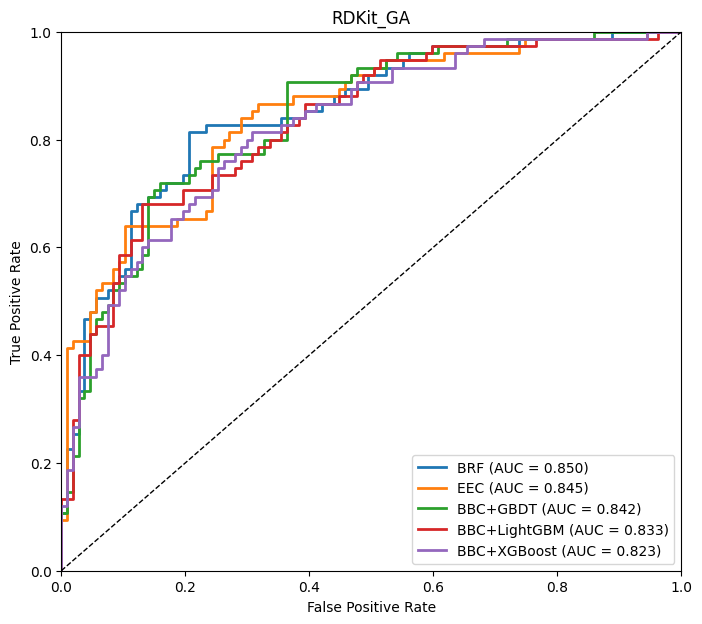

In [37]:
"""
Model comparison: test-set ROC curves
"""
import matplotlib.pyplot as plt

def plot_roc_curves(models, X_test, y_test, title="ROC curves", save_path=None):
    plt.figure(figsize=(8, 7))
    roc_data = {}
    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_data[name] = (fpr, tpr, auc(fpr, tpr))
    for name, (fpr, tpr, a) in sorted(roc_data.items(), key=lambda x: x[1][2], reverse=True):
        plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {a:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlim([0, 1]); plt.ylim([0, 1])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title); plt.legend(loc="lower right")
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

models = {"BRF": model_brf, "EEC": model_eec, "BBC+XGBoost": model_xgb,
          "BBC+GBDT": model_gbc, "BBC+LightGBM": model_lgbm}
plot_roc_curves(models, X_test_selected, Ytest, title="RDKit_GA", save_path="roc_RDKit_GA.png")

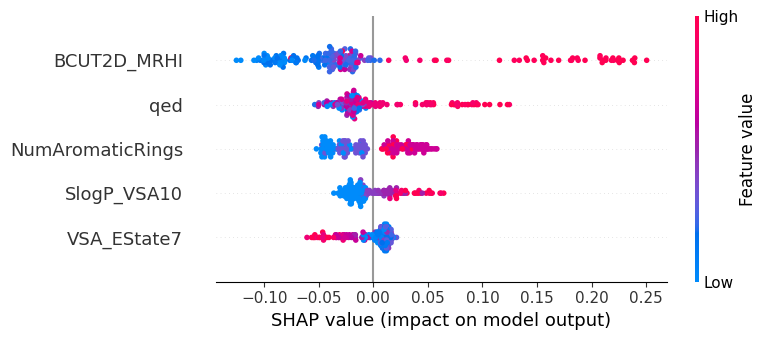

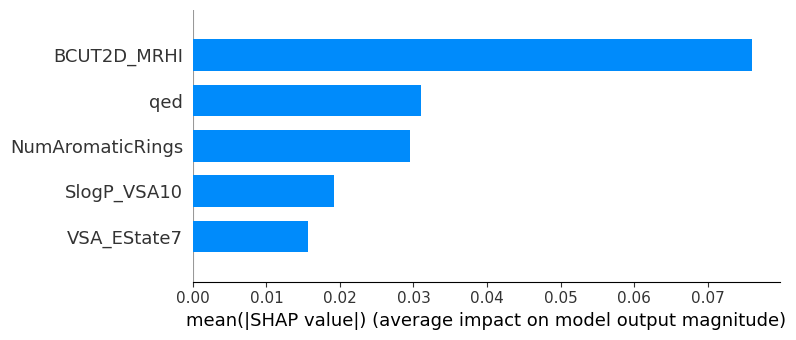

In [34]:
"""
6. Model interpretation with SHAP (best model: RDKit_GA_BRF)

SHAP values are computed on the test set for the best-performing model. A tree explainer is
used for the Balanced Random Forest; for non-tree models a KernelExplainer can be substituted.
"""
import shap

explainer = shap.TreeExplainer(model_brf)
shap_values = explainer.shap_values(X_test_selected)

# positive-class SHAP values (handles differences in SHAP output shape across versions)
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif np.ndim(shap_values) == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

shap.summary_plot(shap_pos, X_test_selected, max_display=5)
shap.summary_plot(shap_pos, X_test_selected, plot_type="bar", max_display=5)